In [1]:
# MVP - Análise da Desvalorização do Real vs Moedas Internacionais vs Inflação
# Autor: Kellman Santana Castro e Silva

## Introdução

O comportamento do câmbio é um dos principais indicadores da economia de um país, refletindo fatores como inflação, política monetária e percepção de risco.

Neste trabalho, analisa-se a desvalorização do real frente a moedas internacionais — dólar, euro, libra e iene — no período de 2015 a 2025. A análise considera também a inflação doméstica (IPCA), permitindo avaliar o ganho ou perda de poder de compra real.

Mas eu tinha uma curiosidade: se eu tivesse investido R$ 1.000,00 (Hum mil Reais em todas as moedas em 2015) em quais delas eu teria o melhor retorno após 10 anos, e no periodo do tempo, em qual momento eu poderia ter um maior ganho.

## Objetivo

- Avaliar a valorização das principais moedas em relação ao real;
- Comparar essa valorização com a inflação acumulada;
- Identificar quais moedas proporcionaram ganho real.
- Como investidor, em qual período poderia ter um maior ganho.

## Metodologia

A análise foi desenvolvida em Python no ambiente Google Colab.

### Fonte de dados

- Banco Central do Brasil (PTAX)
- IPCA (base estruturada em CSV)

### Tratamento dos dados

- Conversão de dados diários para mensais;
- Cálculo da média mensal das cotações;
- Padronização temporal (YYYY-MM);
- Tratamento e alinhamento da série de inflação.

### Construção dos indicadores

Foram criados índices base 100 para permitir comparação entre câmbio e inflação ao longo do tempo.

In [2]:
####Bibliotecas####
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
##### COLETA DADOS BACEM ######

def get_cambio_mensal(moeda, inicio, fim):
    url = f"https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoMoedaPeriodo(moeda='{moeda}',dataInicial='{inicio}',dataFinalCotacao='{fim}')?$format=json"

    try:
        response = requests.get(url)
        data = response.json()

        if 'value' not in data or len(data['value']) == 0:
            return pd.DataFrame()

        df = pd.DataFrame(data['value'])

        df = df[df['tipoBoletim'] == 'Fechamento'].copy()
        df['dataHoraCotacao'] = pd.to_datetime(df['dataHoraCotacao'])
        df['cotacaoVenda'] = df['cotacaoVenda'].astype(float)

        df['ano_mes'] = df['dataHoraCotacao'].dt.to_period('M')

        df_mensal = df.groupby('ano_mes')['cotacaoVenda'].mean().reset_index()

        df_mensal['ano_mes'] = df_mensal['ano_mes'].astype(str)
        df_mensal['moeda'] = moeda

        return df_mensal

    except:
        return pd.DataFrame()

In [4]:
#### PARAMETROS (PERIODO e MOEDAS) #####

moedas = ["USD", "EUR", "GBP", "JPY"]

inicio = "01-01-2015"
fim = "12-31-2025"

In [5]:
#### COLETA #####

dfs = []

for m in moedas:
    df_temp = get_cambio_mensal(m, inicio, fim)

    if not df_temp.empty:
        dfs.append(df_temp)

df_cambio_mensal = pd.concat(dfs, ignore_index=True)

df_cambio_mensal.head()

,ano_mes,cotacaoVenda,moeda
0,2015-01,2.634229,USD
1,2015-02,2.816450,USD
2,2015-03,3.139477,USD
3,2015-04,3.043220,USD
4,2015-05,3.061715,USD


In [6]:
url = "https://raw.githubusercontent.com/kellmancastro/MVP1_PUC_ABR26/main/IPCA.csv"

df_ipca = pd.read_csv(url, encoding="latin-1", sep=";")

df_ipca.head()

,Mes/Ano,VariaÆo Mensal (%),Acumulado no Ano (%)
0,jan/15,1.24,1.24
1,fev/15,1.22,2.47
2,mar/15,1.32,3.82
3,abr/15,0.71,4.56
4,mai/15,0.74,5.34


In [7]:
#### AJUSTAR ARQUIVO ######

df_ipca.columns = ['ano_mes', 'ipca', 'acumulado']

In [8]:
##### TRATAR IPCA ####

df_ipca.columns = ['ano_mes', 'ipca', 'acumulado']

mes_map = {
    'jan': '01', 'fev': '02', 'mar': '03', 'abr': '04',
    'mai': '05', 'jun': '06', 'jul': '07', 'ago': '08',
    'set': '09', 'out': '10', 'nov': '11', 'dez': '12'
}

def converter_data(x):
    mes, ano = x.split('/')
    return f"20{ano}-{mes_map[mes.lower()]}"

df_ipca['ano_mes'] = df_ipca['ano_mes'].apply(converter_data)
df_ipca['ipca'] = df_ipca['ipca'].astype(float)

print("IPCA tratado ✔️")

IPCA tratado ✔️


In [9]:
#### AJUSTAR INDICES BASE 100####

df_ipca = df_ipca.sort_values('ano_mes')
df_ipca['fator'] = 1 + (df_ipca['ipca'] / 100)
df_ipca['ipca_index'] = df_ipca['fator'].cumprod() * 100

df_cambio_mensal = df_cambio_mensal.sort_values(['moeda', 'ano_mes'])
df_cambio_mensal['cambio_index'] = df_cambio_mensal.groupby('moeda')['cotacaoVenda']\
    .transform(lambda x: (x / x.iloc[0]) * 100)

In [10]:
##### BASE FINAL #####
df_plot = df_cambio_mensal.merge(
    df_ipca[['ano_mes', 'ipca_index']],
    on='ano_mes'
)

print("Base integrada ✔️")

Base integrada ✔️


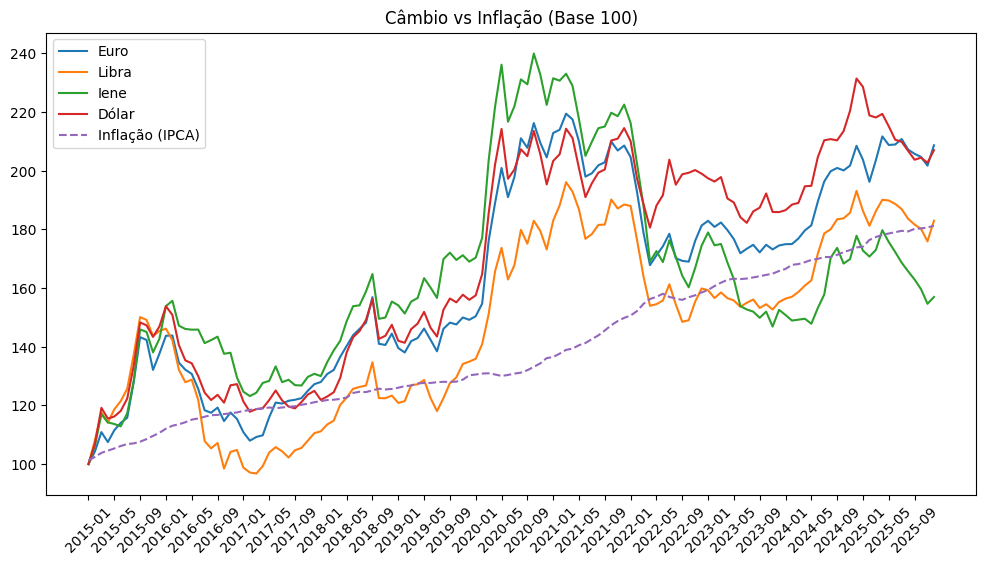

In [11]:
#### GRAFICO 1 CAMBIO MOEDAS VS INFLACAO #####

nomes_moedas = {
    'USD': 'Dólar',
    'EUR': 'Euro',
    'GBP': 'Libra',
    'JPY': 'Iene'
}

plt.figure(figsize=(12,6))

for moeda in df_plot['moeda'].unique():
    df_temp = df_plot[df_plot['moeda'] == moeda]
    plt.plot(df_temp['ano_mes'], df_temp['cambio_index'],
             label=nomes_moedas.get(moeda, moeda))

plt.plot(df_ipca['ano_mes'], df_ipca['ipca_index'],
         linestyle='--', label='Inflação (IPCA)')

idx = np.arange(0, len(df_ipca), 4)
plt.xticks(idx, df_ipca['ano_mes'].iloc[idx], rotation=45)

plt.title('Câmbio vs Inflação (Base 100)')
plt.legend()
plt.show()


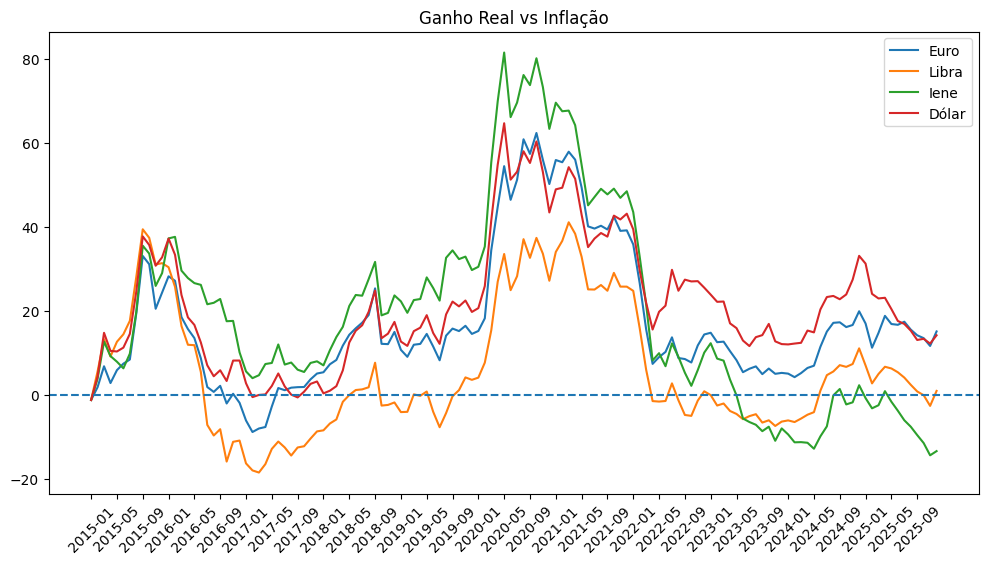

In [12]:
###### GRAFICO 2 - GANHO REAL #######

df_plot['ganho_real_%'] = ((df_plot['cambio_index'] / df_plot['ipca_index']) - 1) * 100

plt.figure(figsize=(12,6))

for moeda in df_plot['moeda'].unique():
    df_temp = df_plot[df_plot['moeda'] == moeda]
    plt.plot(df_temp['ano_mes'], df_temp['ganho_real_%'],
             label=nomes_moedas.get(moeda, moeda))

plt.axhline(0, linestyle='--')

plt.xticks(idx, df_ipca['ano_mes'].iloc[idx], rotation=45)

plt.title('Ganho Real vs Inflação')
plt.legend()
plt.show()

## Resultados

Os resultados demonstram que a valorização das moedas estrangeiras frente ao real não ocorreu de forma uniforme ao longo do período.

Ao considerar a inflação, observa-se que apenas parte das moedas apresentou ganho real:
1 - Dollar e Euro, tiveram valorização acima da inflação (aprox. 20% em ganhos percentuais)
2 - Libra se Manteve alinhada a inflaçao (não se desvalorizou)
3 - Iene desvalorizou em relação a inflação.

Para a Análise do periodo de maior valorização no período, tivemos uma surpresa:

1 - Todas as moedas tiveram maior valorização em relação ao real no período entre o final de 2019, 2020 e 2021 (periodo este compreendido como o inicio da pandemia de covid e sua duração).
2 - Ponto de Surpresa foi o Iene, como a moeda que perdeu para o inflação no períiodo de 10 anos, foi a quem mais teve valorização nos anos da pandemia.

## Conclusão

A análise evidencia que a desvalorização do real deve ser avaliada não apenas sob a ótica nominal, mas também em termos reais. O estudo demonstra que a inflação exerce papel fundamental na interpretação dos resultados, podendo reduzir de forma significativa o ganho aparente relacionado às moedas estrangeiras

Sob a perspectiva de um investidor em busca de ganhos de capital, torna-se claro que crises econômicas, embora desafiadoras, também revelam diversas oportunidades de rentabilização. A chave está em estar preparado para identificar oportunidades, elas podem aparecer quando não se espera.